ML Assignment -1

Dataset: Titanic Dataset (titanic_data_updated.csv)

Total Marks: 100

Email: ******@gmail.com

Name: Muktadir Haque Sarker

Exam Instructions :
- প্রথমে একটি Google Colab ফাইল খুলবে , এরপর প্রথম cell এ নিজের নাম এবং কোর্সে registration করা ইমেইল দিবে
- Question wise numbering করে Text cell রাখবে এবং এর নিচে Code cell থাকবে, চেষ্টা করবে একটি code cell এ একটি question উত্তর দেয়ার
- Google colab এর মধ্যে কোডগুলো করবে
- এবং সেই ফাইলটি ‘Anyone with the link’ & ‘View’ Access দিয়ে ফাইলটির Shareble Link টি সাবমিট করবে।


In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Question 1 (10 Marks)
Load the Titanic dataset and display:
- Dataset shape
- First 10 rows
- 5 random samples

In [92]:
df = pd.read_csv("/content/titanic_data_updated.csv")

In [93]:
print(df.shape)
df.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [94]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
94,95,no,third,"Coxon, Mr. Daniel",male,59.0,0,0,364500,7.2500,NaN,S
620,621,no,third,"Yasbeck, Mr. Antoni",male,27.0,1,0,2659,14.4542,NaN,C
651,652,yes,second,"Doling, Miss. Elsie",female,18.0,0,1,231919,23.0000,NaN,S
355,356,no,third,"Vanden Steen, Mr. Leo Peter",male,28.0,0,0,345783,9.5000,NaN,S
428,429,no,third,"Flynn, Mr. James",male,NaN,0,0,364851,7.7500,NaN,Q


# Question 2 (10 Marks)
Perform feature screening on the Titanic dataset by:
- Finding total missing values
- Finding duplicate rows
- Removing duplicate rows permanently

In [95]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [96]:
df.duplicated().sum()

np.int64(0)

In [97]:
df.drop_duplicates(inplace=True)

# Question 3 (10 Marks)
Perform statistical profiling of the Titanic dataset and display:
- Dataset information
- Statistical summary of numerical columns

Also write 2 observations from the output.


In [98]:
df.info()

# Observation :
#   1. data type & NaN values count.
#   2. Column Counts with frequency.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    object 
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 83.7+ KB


In [99]:
df.describe()

# Observation :
#   1. Neumerical data type
#   2. Statistical summary of each Neumerical Column.

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,29.699118,0.523008,0.381594,32.204208
std,257.353842,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,38.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


# Question 4 (10 Marks)
Perform univariate categorical analysis on the Survived column by:
- Creating a countplot
- Calculating percentage distribution
- Creating a pie chart

Write 2 insights from the analysis.

<Axes: xlabel='Survived', ylabel='count'>

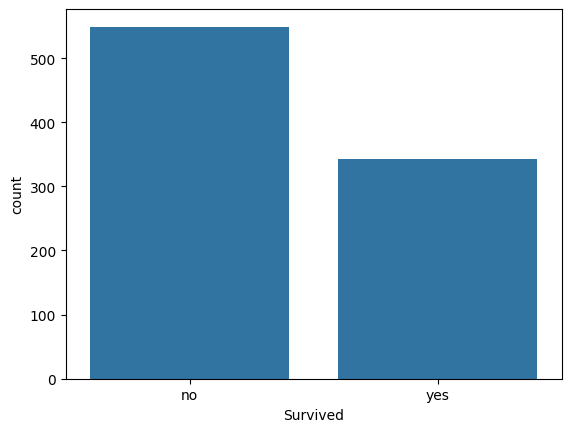

In [100]:
sns.countplot(data=df, x="Survived")

In [101]:
survival_pct = df['Survived'].value_counts(normalize=True) * 100
survival_pct

,proportion
Survived,
no,61.616162
yes,38.383838


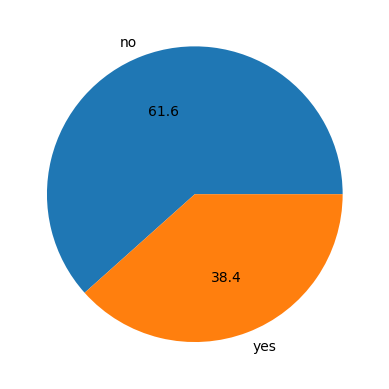

In [102]:
count = df['Survived'].value_counts()
label = df['Survived'].unique()

plt.pie(count, labels=label, autopct="%1.1f")
plt.show()

### insights :  

*   Survived rate is less than not survived.
*   SUrvived count is around 550 and not survived count is arount 350.

# Question 5 (10 Marks)
Perform univariate numerical analysis on the Age column by:
- Creating a histogram
- Creating a KDE plot

Write 2 observations from the plots.


<Axes: xlabel='Age', ylabel='Count'>

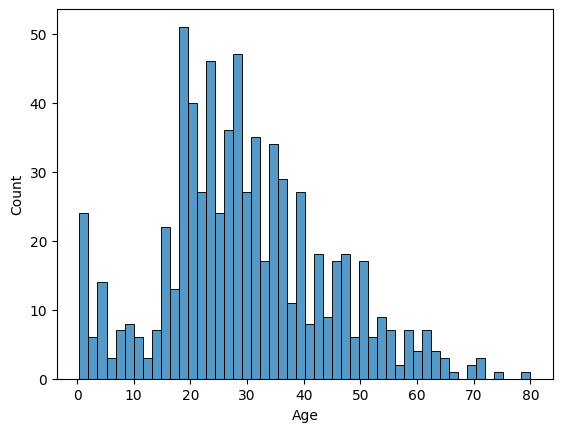

In [103]:
sns.histplot(data=df, x='Age', bins=50)

<Axes: xlabel='Age', ylabel='Density'>

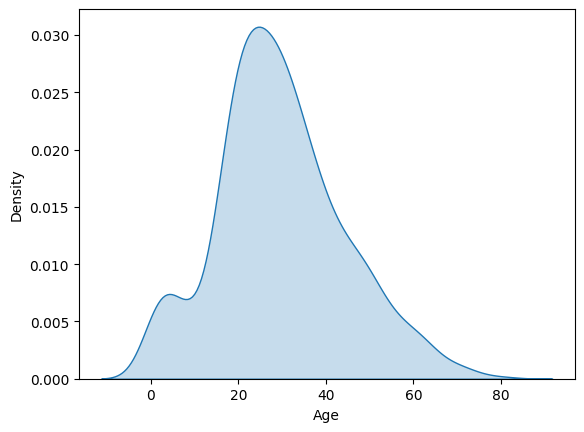

In [104]:
sns.kdeplot(data=df, x='Age', fill=True)

### Observations :

*   Right Skewed
*   Have outliers.

# Question 6 (10 Marks)
Perform multivariate analysis between Sex and Survived using a countplot with hue.

Also calculate normalized survival ratios using groupby().

Write 2 insights from the analysis.


<Axes: xlabel='Survived', ylabel='count'>

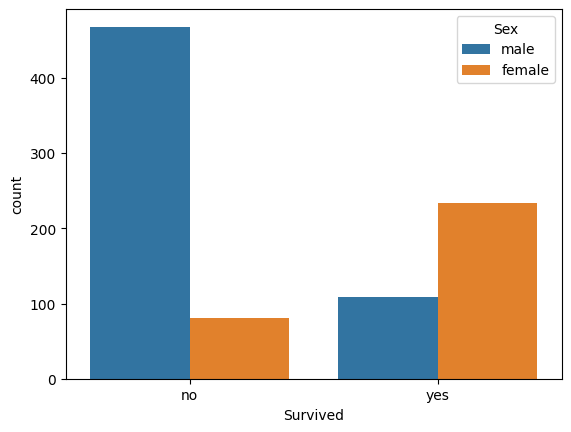

In [105]:
sns.countplot(df, x="Survived", hue='Sex')

In [106]:
gender_split = df.groupby("Sex")['Survived'].value_counts(normalize=True)
gender_split

Sex     Survived
female  yes         0.742038
        no          0.257962
male    no          0.811092
        yes         0.188908
Name: proportion, dtype: float64

### Insights :     
*   Female Survived rate is highter.
*   male survived rate is less than female.

# Question 7 (10 Marks)

Create a barplot showing the relationship between Pclass and Fare.

Write 2 observations from the visualization.


<Axes: xlabel='Pclass', ylabel='Fare'>

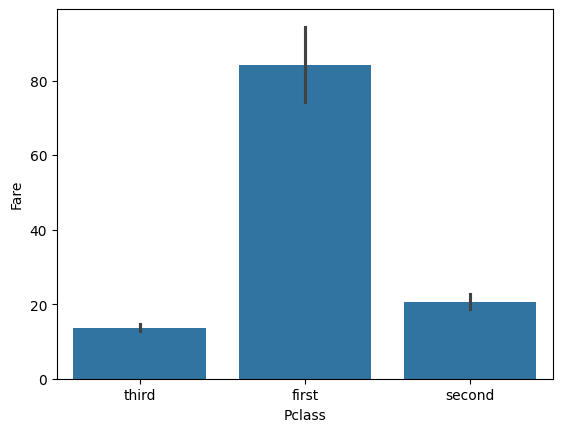

In [107]:
sns.barplot(df, x="Pclass", y="Fare")

### Observations :      
*   Mean farte for first class was 80.
*   lowest fare was for third class which fare was less than 20.

# Question 8 (10 Marks)

Create a KDE plot to compare the Age distribution of survived and non-survived passengers.

Write 2 insights from the graph.


<Axes: xlabel='Age', ylabel='Density'>

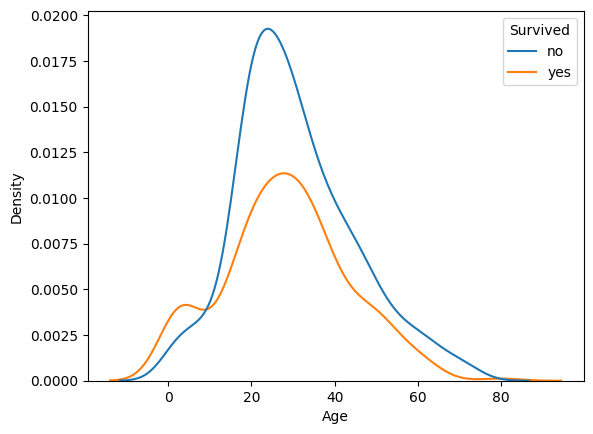

In [108]:
sns.kdeplot(df, x="Age", hue='Survived')

### Insights :     
*   Age between 20-40 survived the most but less than not survived.
*   Tendency of young age people's survive rate is comparetively higher.

###

# Question 9 (10 Marks)
Perform feature engineering and train-test split by:
- Dropping PassengerId, Name, and Ticket columns
- Separating features (X) and target (y)
- Splitting the dataset using test_size=0.2 and random_state=42

Display the shapes of train and test datasets.


In [109]:
df.drop(['PassengerId', "Name", "Ticket"], axis=1)

X=df.drop(['Survived'], axis=1)
y=df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
display(X_train.shape)
display(y_train.shape)

(712, 11)

(712,)

# Question 10 (10 Marks)
Handle missing values in the Titanic dataset by:
- Imputing missing Age values using SimpleImputer with mean strategy
- Imputing missing Embarked values using most frequent strategy
- Imputing missing Cabin values using constant strategy with "Missing"

Finally, check whether any missing values remain.


In [113]:
age_imputer = SimpleImputer(strategy="mean")
age_imputer.fit(X_train[['Age']])
X_train['Age'] = age_imputer.transform(X_train[['Age']])
X_test['Age'] = age_imputer.transform(X_test[['Age']])


embarked_imputer = SimpleImputer(strategy='most_frequent', missing_values=np.nan)
embarked_imputer.fit(X_train[['Embarked']])
X_train[["Embarked"]] = embarked_imputer.transform(X_train[["Embarked"]])
X_test[["Embarked"]] = embarked_imputer.transform(X_test[["Embarked"]])

cabin_imputer = SimpleImputer(strategy='constant', fill_value="Missing", missing_values=np.nan)
cabin_imputer.fit(X_train[["Cabin"]])

X_train[["Cabin"]] = cabin_imputer.transform(X_train[['Cabin']])
X_test[["Cabin"]] = cabin_imputer.transform(X_test[['Cabin']])

In [114]:
X_train.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,0


In [115]:
X_test.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,0
